In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [15]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [16]:
print("Shape of dataset:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (150, 4)

Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [17]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

X_scaled = pd.DataFrame(X_scaled, columns=df.columns)

X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [18]:
#Provide a brief description of how KMeans clustering works.
#KMeans is an unsupervised machine learning algorithm that is used to divide data into a certain number of groups, which are called clusters
#The basic steps of KMeans are:
#It first selects some points as the cluster centers (centroids)
#Each data point is then assigned to the nearest centroid
#After that, the centroids are recalculated based on the assigned data points
#These steps are repeated until the clusters become stable and there are no major changes
#For the Iris dataset, we can use 3 clusters because the dataset contains three different types of Iris flowers

In [19]:
#Explain why KMeans clustering might be suitable for the Iris dataset.

#KMeans is a good choice for the Iris dataset because it contains numerical features like sepal length, sepal width, petal length, and petal width
#Since these values are numerical, we can measure the distance between the data points, which is important for the KMeans algorithm
#Iris dataset also has three different types of flowers, so using 3 clusters makes sense for this dataset
# KMeans can help us group the flowers based on the similarities in their features

In [20]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

kmeans_labels = kmeans.fit_predict(X_scaled)

kmeans_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

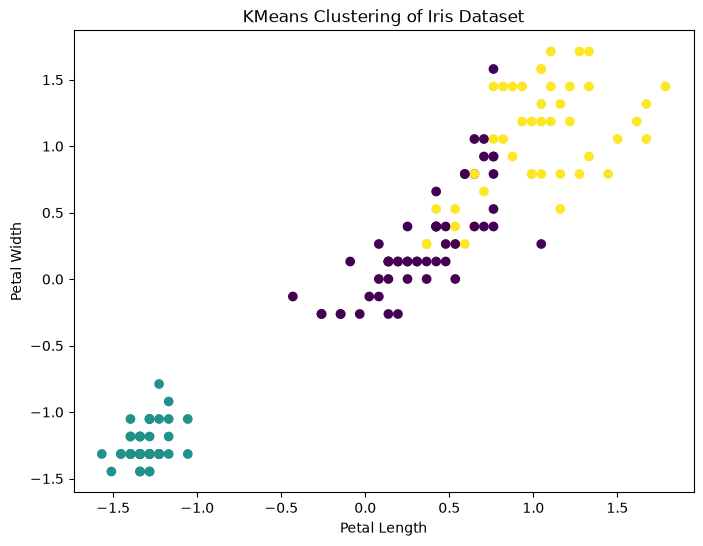

In [21]:
plt.figure(figsize=(8, 6))

plt.scatter(X_scaled.iloc[:, 2],X_scaled.iloc[:, 3],c=kmeans_labels,cmap="viridis")

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("KMeans Clustering of Iris Dataset")

plt.show()

In [22]:
print("Cluster Centers:")
print(kmeans.cluster_centers_)

Cluster Centers:
[[-0.05021989 -0.88337647  0.34773781  0.2815273 ]
 [-1.01457897  0.85326268 -1.30498732 -1.25489349]
 [ 1.13597027  0.08842168  0.99615451  1.01752612]]


In [23]:
#These points represent the centers of the three clusters calculated by KMeans

In [24]:
#Provide a brief description of how Hierarchical clustering works.

#Hierarchical clustering is an unsupervised method that groups similar data points and builds a hierarchy of clusters.
#It starts with each data point as its own cluster, then slowly merges the most similar clusters.
#this continues until all points form one large cluster.
#A dendrogram is used to visually show this process

In [25]:
#Explain why Hierarchical clustering might be suitable for the Iris dataset.


#Hierarchical clustering is suitable for the Iris dataset because it contains numerical features such as sepal length,
#sepal width, petal length, and petal width. These features can be used to find similarities between different flowers.
#Another advantage is that we can use a dendrogram to easily visualize how the different data points are related to each other and 
#how they form clusters

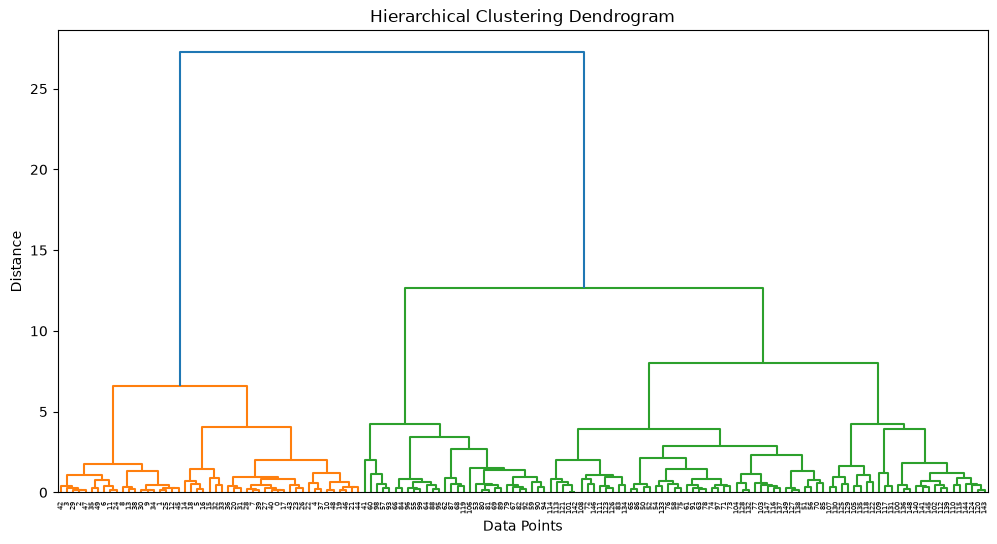

In [26]:
linked = linkage(X_scaled, method="ward")

plt.figure(figsize=(12, 6))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")

plt.show()

In [27]:
hierarchical = AgglomerativeClustering(n_clusters=3,linkage="ward")

hierarchical_labels = hierarchical.fit_predict(X_scaled)

hierarchical_labels

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 0, 2, 0,
       2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

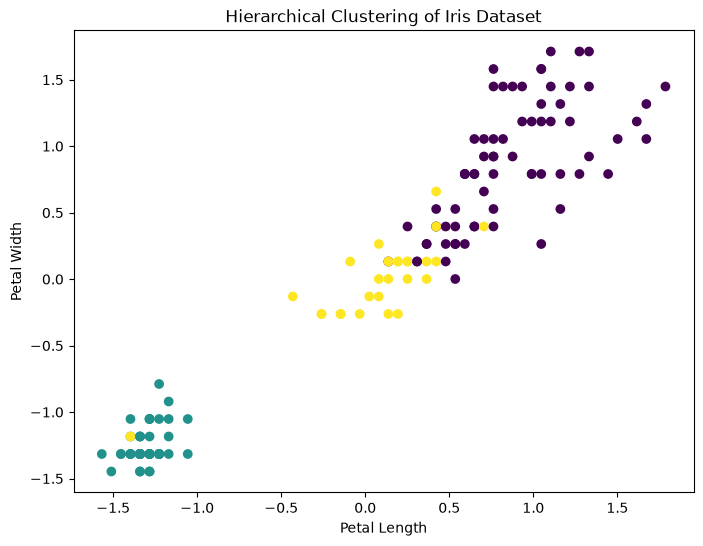

In [28]:
plt.figure(figsize=(8, 6))

plt.scatter(X_scaled.iloc[:, 2],X_scaled.iloc[:, 3],c=hierarchical_labels,cmap="viridis")

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Hierarchical Clustering of Iris Dataset")

plt.show()

In [29]:
comparison = pd.DataFrame({"KMeans": kmeans_labels,"Hierarchical": hierarchical_labels})

comparison.head(10)

,KMeans,Hierarchical
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,1,1
9,1,1


In [30]:
print("KMeans Cluster Counts:")
print(pd.Series(kmeans_labels).value_counts())

print("\nHierarchical Cluster Counts:")
print(pd.Series(hierarchical_labels).value_counts())

KMeans Cluster Counts:
0    53
1    50
2    47
Name: count, dtype: int64

Hierarchical Cluster Counts:
0    71
1    49
2    30
Name: count, dtype: int64


In [31]:
#Both KMeans and Hierarchical Clustering work well with the Iris dataset
#KMeans is simple and fast, especially when the number of clusters is known
#Hierarchical Clustering helps us understand how the data points are related and shows this clearly using a dendrogram
#Overall, both methods can identify meaningful groups in the Iris dataset